In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.combine import SMOTEENN

In [2]:
db = pd.read_csv('Custom_CNN_Features.csv')

In [3]:
print(db.dtypes)

Filename        object
Class Label      int64
f0             float64
f1             float64
f2             float64
                ...   
f195           float64
f196           float64
f197           float64
f198           float64
f199           float64
Length: 202, dtype: object


In [4]:
print(db.isnull().sum())

Filename       0
Class Label    0
f0             0
f1             0
f2             0
              ..
f195           0
f196           0
f197           0
f198           0
f199           0
Length: 202, dtype: int64


In [5]:
class_distribution = db['Class Label'].value_counts()

In [6]:
print(class_distribution)

Class Label
1    1634
0    1055
2     564
Name: count, dtype: int64


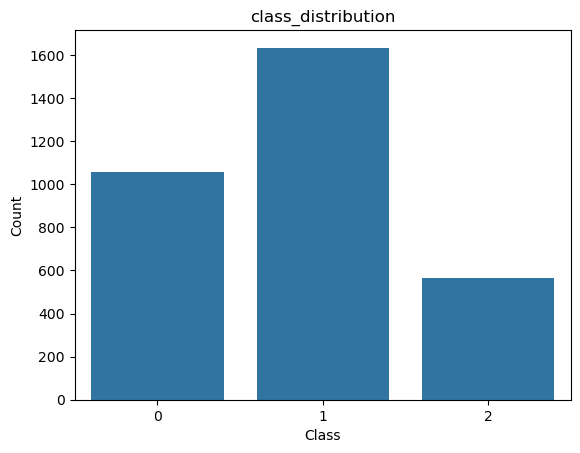

In [7]:
sns.countplot(x = 'Class Label', data = db )
plt.title('class_distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [12]:
X = db.drop(columns=['Class Label'])
y = db['Class Label']
#one-hot encoding for nominal categories
string_columns = X.select_dtypes(include= ['object']).columns
print(string_columns)


Index(['Filename'], dtype='object')


In [15]:
# Convert the string column to one-hot encoded columns
X = pd.get_dummies(X, columns=['string_columns'], drop_first=True)

# Fill missing values with a placeholder
X['string_columns'] = X['string_columns'].fillna('missing')

# Or drop rows with missing values
X = X.dropna(subset=['string_columns'])


KeyError: "None of [Index(['string_columns'], dtype='object')] are in the [columns]"

In [ ]:
#hybrid sampling for balancing the data
smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X, y)